# Synthetic Lorenz Dataset Generation and Visualization
This notebook generates a synthetic Lorenz dataset (200 trials x 50 neurons) and visualizes the ground truth latents, behavior, and neural firing rates.

In [117]:
import numpy as np
import torch
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set seeds
seed = 1
torch.manual_seed(seed)
np.random.seed(seed)

# Parameters
n_neurons = 50
n_latents_true = 3
n_bins = 100
dt = 20 / 1000.0  # 20ms bin size
n_behavior = 2
behavior_noise_std = 0.1
delay_bins = 8  # Behavior delay bins

print(f"Seed: {seed}, Neurons: {n_neurons}, Bins: {n_bins}, dt: {dt}s, delay_bins: {delay_bins}")

Seed: 1, Neurons: 50, Bins: 100, dt: 0.02s, delay_bins: 8


In [118]:
# Initialize Global Readout Matrices
C = 1.0 * torch.randn(n_neurons, n_latents_true)
d = 0.0 + 0.2 * torch.randn(n_neurons)
C_vel = torch.randn(n_behavior, n_latents_true)
B_in = torch.eye(n_latents_true)

# Single fixed direction in latent space for on-manifold kicks
direction_vec = np.random.randn(n_latents_true)
direction_vec = direction_vec / np.linalg.norm(direction_vec)
print(f"Fixed Direction Vector: {direction_vec}")

# Off-manifold input footprint (orthogonal to C)
gen_input_vec = torch.randn(C.shape[0])
C_pinv = torch.linalg.pinv(C)
ortho_input_vec = gen_input_vec - C @ C_pinv @ gen_input_vec
ortho_input_vec = ortho_input_vec / torch.linalg.norm(ortho_input_vec)

Fixed Direction Vector: [ 0.89529806 -0.33718466 -0.29111491]


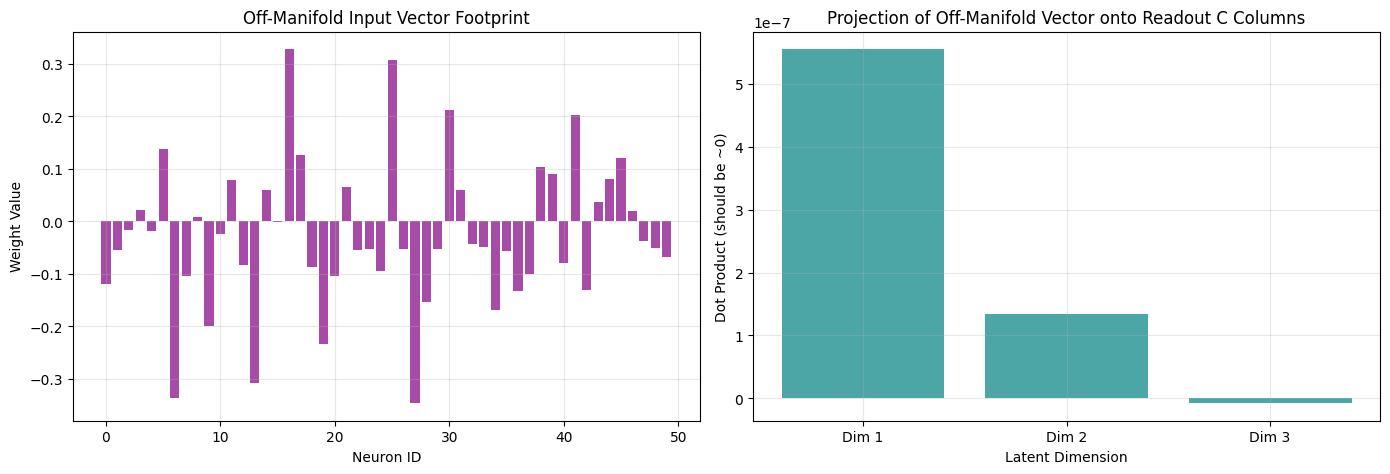

In [119]:
# Plot the off-manifold input footprint vector across neurons and verify its orthogonality to C
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Component weights of the off-manifold vector across all neurons
axs[0].bar(range(n_neurons), ortho_input_vec.numpy(), color='purple', alpha=0.7)
axs[0].set_title("Off-Manifold Input Vector Footprint")
axs[0].set_xlabel("Neuron ID")
axs[0].set_ylabel("Weight Value")
axs[0].grid(True, alpha=0.3)

# Projection/dot product of ortho_input_vec onto columns of C
projection = torch.matmul(C.T, ortho_input_vec)
axs[1].bar(range(n_latents_true), projection.numpy(), color='teal', alpha=0.7)
axs[1].set_title("Projection of Off-Manifold Vector onto Readout C Columns")
axs[1].set_xlabel("Latent Dimension")
axs[1].set_ylabel("Dot Product (should be ~0)")
axs[1].set_xticks(range(n_latents_true))
axs[1].set_xticklabels([f"Dim {i+1}" for i in range(n_latents_true)])
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [120]:
def lorenz_dynamics(state, t, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

def simulate_lorenz(n_trials, perturbed_ratio=0.0):
    y_list, vel_list, z_list, u_list = [], [], [], []
    
    burn_in_time = 1.0
    dt_integration = 0.005
    steps_per_bin = int(dt / dt_integration)

    kick_prob = 0.05
    kick_magnitude = 5.0
    off_manifold_kick_magnitude = 5.0
    n_inputs = n_latents_true
    n_bins_sim = n_bins + abs(delay_bins)

    for _ in range(n_trials):
        is_perturbed_trial = np.random.rand() < perturbed_ratio

        state = np.random.randn(3) * 5.0 + np.array([0, 0, 20])
        t_burn = np.arange(0, burn_in_time, dt_integration)
        burn_states = odeint(lorenz_dynamics, state, t_burn)
        state = burn_states[-1]

        trial_z, trial_y, trial_v, trial_u = [], [], [], []

        for b in range(n_bins_sim):
            u_bin = np.zeros(n_inputs)
            off_manifold_inputs = torch.zeros(n_neurons)

            # Apply Kick
            if is_perturbed_trial and (np.random.rand() < kick_prob):
                u_bin = direction_vec * kick_magnitude
                state = state + (B_in.numpy() @ u_bin)
                off_manifold_inputs = ortho_input_vec * off_manifold_kick_magnitude

            t_bin = np.linspace(0, dt, steps_per_bin + 1)
            bin_states = odeint(lorenz_dynamics, state, t_bin)
            state = bin_states[-1]

            z_bin_raw = np.mean(bin_states[:-1], axis=0)
            z_bin_scaled = (z_bin_raw - np.array([0, 0, 25.0])) / 10.0
            z_bin_scaled = z_bin_scaled + np.array([2, 2, 2])
            z_tensor = torch.tensor(z_bin_scaled, dtype=torch.float32)

            pre_rate_activation = torch.matmul(z_tensor, C.T) + d + off_manifold_inputs
            rate = torch.clamp(torch.exp(pre_rate_activation), max=1000.0) * dt
            spikes = torch.poisson(rate)

            vel = torch.matmul(z_tensor, C_vel.T) + behavior_noise_std * torch.randn(n_behavior)

            trial_z.append(z_tensor)
            trial_y.append(spikes)
            trial_v.append(vel)
            trial_u.append(torch.tensor(u_bin, dtype=torch.float32))

        y_stacked = torch.stack(trial_y)
        v_stacked = torch.stack(trial_v)
        z_stacked = torch.stack(trial_z)
        u_stacked = torch.stack(trial_u)

        if delay_bins >= 0:
            y_sliced = y_stacked[delay_bins : delay_bins + n_bins]
            z_sliced = z_stacked[delay_bins : delay_bins + n_bins]
            u_sliced = u_stacked[delay_bins : delay_bins + n_bins]
            v_sliced = v_stacked[0 : n_bins]
        else:
            abs_delay = abs(delay_bins)
            y_sliced = y_stacked[0 : n_bins]
            z_sliced = z_stacked[0 : n_bins]
            u_sliced = u_stacked[0 : n_bins]
            v_sliced = v_stacked[abs_delay : abs_delay + n_bins]

        y_list.append(y_sliced)
        vel_list.append(v_sliced)
        z_list.append(z_sliced)
        u_list.append(u_sliced)

    return torch.stack(y_list), torch.stack(vel_list), torch.stack(z_list), torch.stack(u_list)

print("Simulating 200 training trials (30% perturbed)...")
train_y, train_v, train_z, train_u = simulate_lorenz(200, perturbed_ratio=0.3)
print(f"Latents shape: {train_z.shape}")
print(f"Spikes shape: {train_y.shape}")
print(f"Behavior shape: {train_v.shape}")

Simulating 200 training trials (30% perturbed)...
Latents shape: torch.Size([200, 100, 3])
Spikes shape: torch.Size([200, 100, 50])
Behavior shape: torch.Size([200, 100, 2])


### 3D Visualizations of Lorenz Trials with on manifold Perturbations

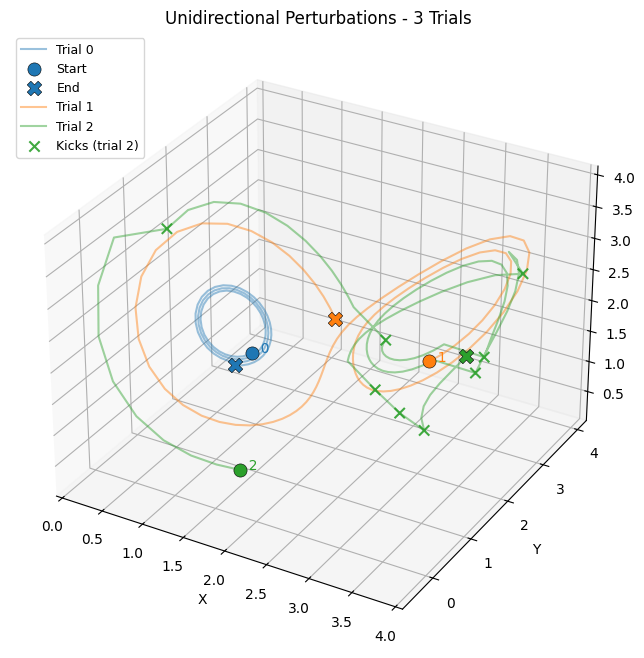

In [121]:
# Find a trial with perturbations to visualize
kick_counts = [torch.sum(u.abs()).item() for u in train_u]
trial_idx = np.argmax(kick_counts)
z_trial = train_z[trial_idx].numpy()
u_trial = train_u[trial_idx].numpy()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot 3 random trials
cmap = plt.get_cmap("tab10")
for i in range(3):
    c = cmap(i)
    z_plot = train_z[i].numpy()
    u_plot = train_u[i].numpy()
    
    ax.plot(
        z_plot[:, 0], z_plot[:, 1], z_plot[:, 2],
        color=c, alpha=0.45, linewidth=1.5,
        label=f"Trial {i}"
    )
    
    # Mark start and end points
    ax.scatter(
        z_plot[0, 0], z_plot[0, 1], z_plot[0, 2],
        s=90, marker="o", color=c, edgecolor="k", linewidth=0.4, zorder=20,
        label="Start" if i == 0 else None
    )
    ax.scatter(
        z_plot[-1, 0], z_plot[-1, 1], z_plot[-1, 2],
        s=110, marker="X", color=c, edgecolor="k", linewidth=0.4, zorder=20,
        label="End" if i == 0 else None
    )
    
    ax.text(
        z_plot[0, 0], z_plot[0, 1], z_plot[0, 2],
        f"  {i}", color=c, fontsize=10, zorder=30
    )

    # Plot kicks for this trial if they exist
    kick_idxs = np.where(np.linalg.norm(u_plot, axis=1) > 0)[0]
    if len(kick_idxs) > 0:
        ax.scatter(
            z_plot[kick_idxs, 0], z_plot[kick_idxs, 1], z_plot[kick_idxs, 2],
            color=c, s=55, marker="x", alpha=0.9,
            label=f"Kicks (trial {i})"
        )

ax.set_title('Unidirectional Perturbations - 3 Trials')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend(loc="upper left", fontsize=9)
plt.show()

### 2. 1D Timeseries (State and Input Kicks)

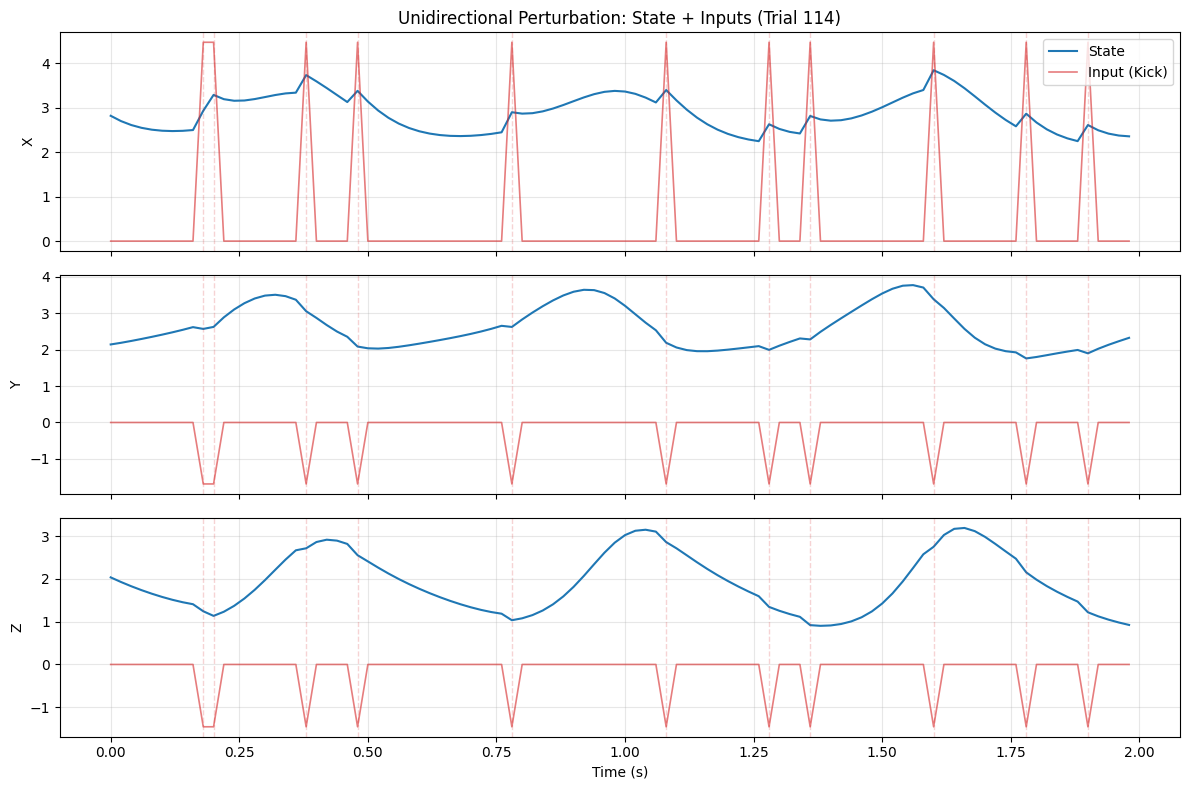

In [122]:
# Visualizing a single trial timeseries (X, Y, Z + Inputs)
time = np.arange(n_bins) * dt

kick_idxs = np.where(np.linalg.norm(u_trial, axis=1) > 0)[0]
kick_times = time[kick_idxs]

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
dims = ["X", "Y", "Z"]

for i in range(3):
    axs[i].plot(time, z_trial[:, i], color="tab:blue", linewidth=1.5, label="State")
    axs[i].plot(time, u_trial[:, i], color="tab:red", alpha=0.6, linewidth=1.2, label="Input (Kick)")

    for kt in kick_times:
        axs[i].axvline(kt, color="tab:red", linestyle="--", alpha=0.2, linewidth=1.0)

    axs[i].set_ylabel(dims[i])
    axs[i].grid(True, alpha=0.3)

axs[0].legend(loc="upper right")
axs[0].set_title(f"Unidirectional Perturbation: State + Inputs (Trial {trial_idx})")
axs[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


### 3. Downstream Outputs: Neural Spikes and Behavior

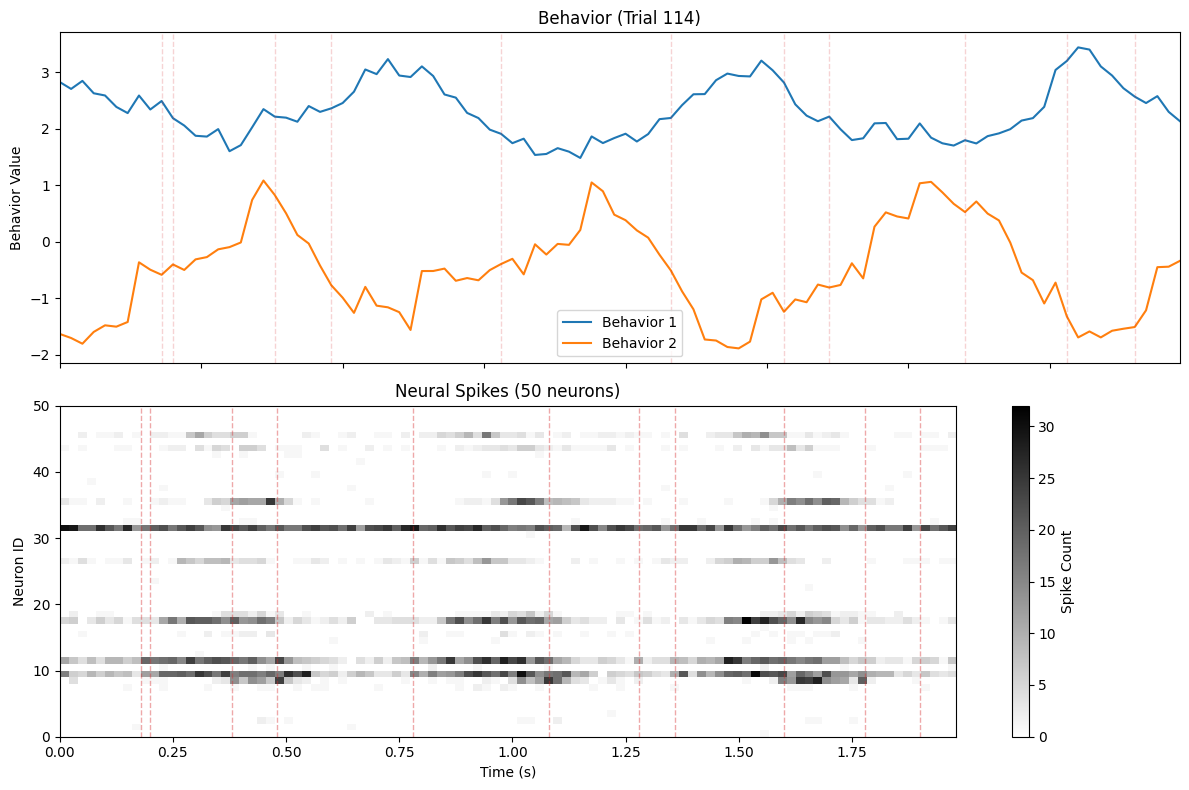

In [123]:
# Visualize Behavior and Neural Spikes for the same trial
v_trial = train_v[trial_idx].numpy()
y_trial = train_y[trial_idx].numpy()

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Behavior
axs[0].plot(time, v_trial[:, 0], label="Behavior 1")
axs[0].plot(time, v_trial[:, 1], label="Behavior 2")
for kt in kick_times:
    axs[0].axvline(kt, color="tab:red", linestyle="--", alpha=0.2, linewidth=1.0)
axs[0].set_title(f'Behavior (Trial {trial_idx})')
axs[0].set_ylabel('Behavior Value')
axs[0].legend()

# Neural Spikes
im = axs[1].imshow(y_trial.T, aspect='auto', interpolation='nearest', cmap='gray_r', extent=[time[0], time[-1], 0, n_neurons])
axs[1].set_title(f'Neural Spikes ({n_neurons} neurons)')
axs[1].set_ylabel('Neuron ID')
axs[1].set_xlabel('Time (s)')
for kt in kick_times:
    axs[1].axvline(kt, color="tab:red", linestyle="--", alpha=0.4, linewidth=1.0)

plt.colorbar(im, ax=axs[1], label='Spike Count')

plt.tight_layout()
plt.show()

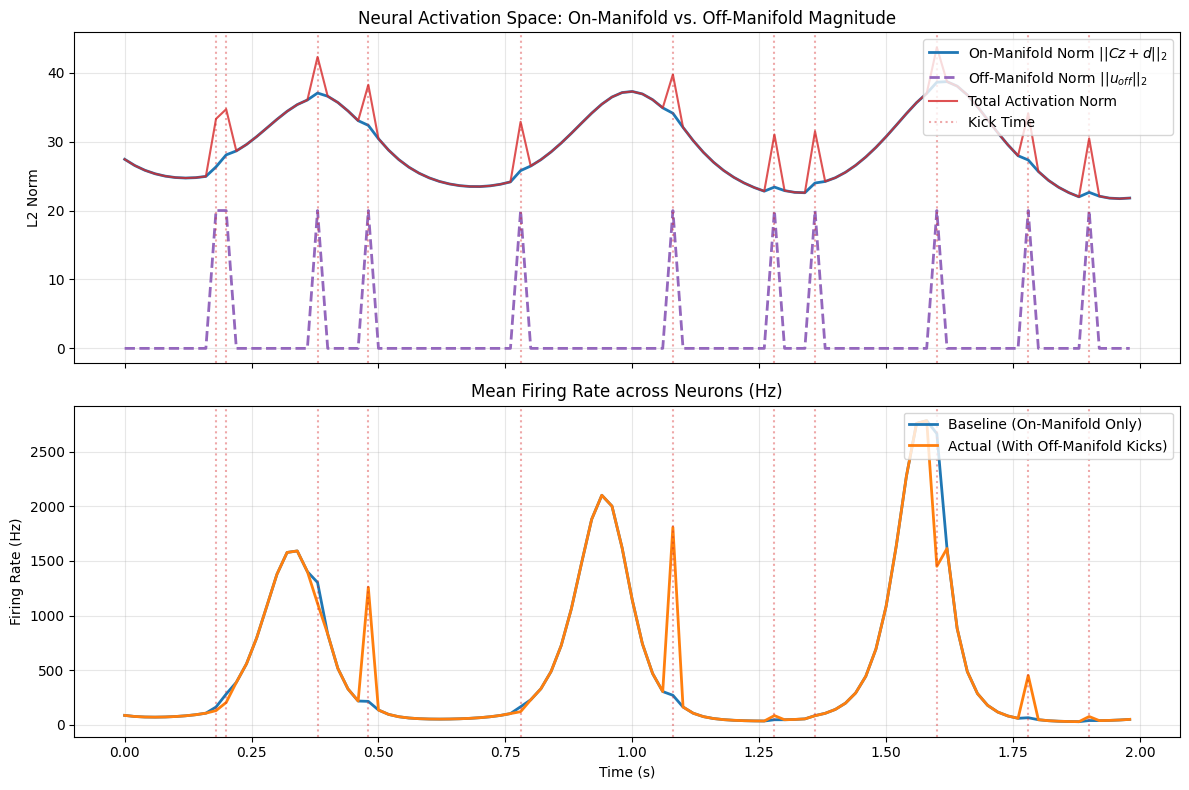

In [126]:
# Visualize the off-manifold magnitude relative to on-manifold neural activity
# We use the trial with the most kicks.

# 1. Compute L2 norms in Neural Space
z_trial_tensor = train_z[trial_idx]
u_trial_tensor = train_u[trial_idx]

norm_on_manifold = []
norm_off_manifold = []
norm_total = []

mean_rate_on = []
mean_rate_total = []

off_manifold_mag = 20.0 

for b in range(n_bins):
    # On-manifold log-activation: C @ z + d
    act_on = torch.matmul(z_trial_tensor[b], C.T) + d
    
    # Off-manifold log-activation: ortho_input_vec * magnitude if kick occured
    has_kick = u_trial_tensor[b].abs().sum() > 0
    act_off = ortho_input_vec * off_manifold_mag if has_kick else torch.zeros(n_neurons)
    
    act_total = act_on + act_off
    
    norm_on_manifold.append(torch.norm(act_on).item())
    norm_off_manifold.append(torch.norm(act_off).item())
    norm_total.append(torch.norm(act_total).item())

# 2. Compute Firing Rates (Hz) to show the effect in firing rate space
# rate = exp(activation)
 
    rate_on = torch.exp(act_on)  
    rate_total = torch.exp(act_total) 
    
    mean_rate_on.append(torch.mean(rate_on).item())
    mean_rate_total.append(torch.mean(rate_total).item())

# Plotting
time = np.arange(n_bins) * dt
kick_idxs = np.where(u_trial_tensor.abs().sum(dim=1) > 0)[0]
kick_times = time[kick_idxs]

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top panel: Activation Space Norms
axs[0].plot(time, norm_on_manifold, color="tab:blue", linewidth=2.0, label="On-Manifold Norm $||C z + d||_2$")
axs[0].plot(time, norm_off_manifold, color="tab:purple", linewidth=2.0, linestyle="--", label="Off-Manifold Norm $||u_{off}||_2$")
axs[0].plot(time, norm_total, color="tab:red", linewidth=1.5, alpha=0.8, label="Total Activation Norm")
for kt in kick_times:
    axs[0].axvline(kt, color="tab:red", linestyle=":", alpha=0.4, label="Kick Time" if kt == kick_times[0] else "")
axs[0].set_title("Neural Activation Space: On-Manifold vs. Off-Manifold Magnitude")
axs[0].set_ylabel("L2 Norm")
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc="upper right")

# Bottom panel: Firing Rate comparison (Hz)
axs[1].plot(time, mean_rate_on, color="tab:blue", linewidth=2.0, label="Baseline (On-Manifold Only)")
axs[1].plot(time, mean_rate_total, color="tab:orange", linewidth=2.0, label="Actual (With Off-Manifold Kicks)")
for kt in kick_times:
    axs[1].axvline(kt, color="tab:red", linestyle=":", alpha=0.4)
axs[1].set_title("Mean Firing Rate across Neurons (Hz)")
axs[1].set_ylabel("Firing Rate (Hz)")
axs[1].set_xlabel("Time (s)")
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc="upper right")

plt.tight_layout()
plt.show()
